#### <font color='#1F4E79' size='16' face='Calibri'><b>Behavioural Pattern Analysis Using Multi-Modal Lifelog Data</b></font>

---

<div style="font-family:'Calibri'; font-size:19px; color:black;">

* **Author:** Ghulam Mohiuddin 
* **Course:** Dissertation
* **Supervision:** Prof. William Morrison
* **Institution:** GISMA University of Applied Sciences  
* **Date:** March 2026  

</div>

---

#### <font color='#1F4E79' size='14' face='Calibri'><b>1. Introduction</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

This study analyses behavioural patterns using multi-modal data from wearable devices and smartphones.

The objective is to understand daily behaviour, identify patterns using clustering, and analyse their relationship with lifestyle factors such as sleep, stress, and fatigue.

</div>

# <font color='#1F4E79' size='10' face='Calibri'><b>2. Data Overview</b></font>

<div style="font-family:'Calibri'; font-size:18px; color:black;">

The dataset includes multiple data sources collected from wearable and mobile sensors.

The following data types are used:
- Activity data (movement patterns)
- Heart rate data
- Step count
- Phone usage behaviour
- Screen interaction
- Light exposure

These features provide a comprehensive representation of daily physical and digital behaviour.

</div>

#### <font color='#1F4E79' size='14' face='Calibri'><b>3. Data Preprocessing</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

The data is converted into daily-level format by aggregating values per user per day.

Key features such as activity count, heart rate statistics, total steps, usage time, and light exposure are extracted.

</div>

In [88]:
import os
import pandas as pd
from pathlib import Path

## 3.2: Set dataset path

In [89]:
base_path = Path("/kaggle/input")

# Find all parquet and csv files recursively
data_files = list(base_path.glob("**/*.parquet")) + list(base_path.glob("**/*.csv"))

print(f"Total files found: {len(data_files)}")

# Show some files
for f in data_files[:10]:
    print(f)

Total files found: 13
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mWifi.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mAmbience.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mLight.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_wLight.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mGps.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mUsageStats.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_wHr.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mScreenStatus.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_mBle.parquet
/kaggle/input/datasets/tayyebmohiuddin/etri-24/ch2025_wPedo.parquet


## 3.3: Separate files by type

In [90]:
parquet_files = [f for f in data_files if f.suffix == ".parquet"]
csv_files = [f for f in data_files if f.suffix == ".csv"]

print("Parquet files:", len(parquet_files))
print("CSV files:", len(csv_files))

Parquet files: 12
CSV files: 1


## 3.4: Load ONE sample file (safe start)

In [91]:
first_file = parquet_files[0]

data = pd.read_parquet(first_file)

print("File loaded:", first_file.name)
data.head()

File loaded: ch2025_mWifi.parquet


,subject_id,timestamp,m_wifi
0,id01,2024-06-26 12:03:00,"[{'bssid': 'a0:0f:37:9a:5d:8b', 'rssi': -78}, ..."
1,id01,2024-06-26 12:13:00,"[{'bssid': 'a0:0f:37:9a:5d:8b', 'rssi': -79}, ..."
2,id01,2024-06-26 12:23:00,"[{'bssid': '10:e3:c7:0a:74:d1', 'rssi': -78}, ..."
3,id01,2024-06-26 12:33:00,"[{'bssid': '10:e3:c7:09:7f:bc', 'rssi': -80}, ..."
4,id01,2024-06-26 12:43:00,"[{'bssid': '56:46:ae:59:b1:13', 'rssi': -44}, ..."


## 3.5: Understand structure

In [92]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76336 entries, 0 to 76335
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   subject_id  76336 non-null  object        
 1   timestamp   76336 non-null  datetime64[ns]
 2   m_wifi      76336 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 1.7+ MB


## 3.6: Check Columns

In [93]:
print("Columns:", list(data.columns))

Columns: ['subject_id', 'timestamp', 'm_wifi']


#### <font color='#1F4E79' size='14' face='Calibri'><b>4. Data Understanding</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

The dataset is divided into multiple files, and each file contains a specific type of information collected over time.

Before starting any processing, I go through all the files to understand their structure, number of records, and column names. This helps in identifying which data is relevant for the analysis.

In [94]:
file_info = []

for file in parquet_files:
    df = pd.read_parquet(file)
    
    file_info.append({
        "file_name": file.name,
        "rows": df.shape[0],
        "columns": list(df.columns)
    })

file_info_df = pd.DataFrame(file_info)
file_info_df

,file_name,rows,columns
0,ch2025_mWifi.parquet,76336,"[subject_id, timestamp, m_wifi]"
1,ch2025_mAmbience.parquet,476577,"[subject_id, timestamp, m_ambience]"
2,ch2025_mLight.parquet,96258,"[subject_id, timestamp, m_light]"
3,ch2025_wLight.parquet,633741,"[subject_id, timestamp, w_light]"
4,ch2025_mGps.parquet,800611,"[subject_id, timestamp, m_gps]"
5,ch2025_mUsageStats.parquet,45197,"[subject_id, timestamp, m_usage_stats]"
6,ch2025_wHr.parquet,382918,"[subject_id, timestamp, heart_rate]"
7,ch2025_mScreenStatus.parquet,939653,"[subject_id, timestamp, m_screen_use]"
8,ch2025_mBle.parquet,21830,"[subject_id, timestamp, m_ble]"
9,ch2025_wPedo.parquet,748100,"[subject_id, timestamp, step, step_frequency, ..."


For this study, not all files are used. Instead, a subset of relevant data sources is selected to represent different aspects of daily behaviour.

The selected data includes:
- Activity data (movement patterns)
- Heart rate data
- Step count
- Phone usage behaviour
- Screen interaction patterns
- Light exposure

These data sources together help capture both physical activity and daily lifestyle behaviour.

In total, around 5-6 files are used, from which multiple features are created at a daily level. This allows a more complete understanding of behaviour compared to using only a single type of data.

In [95]:
keywords = ["mActivity", "wHr", "wPedo", "mUsageStats", "mScreenStatus", "mLight"]

selected_files = [f for f in parquet_files if any(k in f.name for k in keywords)]

for f in selected_files:
    print(f.name)

ch2025_mLight.parquet
ch2025_mUsageStats.parquet
ch2025_wHr.parquet
ch2025_mScreenStatus.parquet
ch2025_wPedo.parquet
ch2025_mActivity.parquet


In [96]:
data_dict = {}

for file in selected_files:
    df = pd.read_parquet(file)
    
    data_dict[file.name] = df
    
    print("\nFile:", file.name)
    print(df.head(2))


File: ch2025_mLight.parquet
  subject_id           timestamp  m_light
0       id01 2024-06-26 12:03:00    534.0
1       id01 2024-06-26 12:13:00    846.0

File: ch2025_mUsageStats.parquet
  subject_id           timestamp  \
0       id01 2024-06-26 13:00:00   
1       id01 2024-06-26 13:10:00   

                                       m_usage_stats  
0  [{'app_name': ' 캐시워크', 'total_time': 69}, {'ap...  
1  [{'app_name': '통화', 'total_time': 26419}, {'ap...  

File: ch2025_wHr.parquet
  subject_id           timestamp  \
0       id01 2024-06-26 12:23:00   
1       id01 2024-06-26 12:24:00   

                                          heart_rate  
0  [134, 134, 135, 133, 134, 135, 134, 135, 134, ...  
1  [123, 122, 121, 120, 121, 121, 120, 118, 119, ...  

File: ch2025_mScreenStatus.parquet
  subject_id           timestamp  m_screen_use
0       id01 2024-06-26 12:03:00             0
1       id01 2024-06-26 12:04:00             0

File: ch2025_wPedo.parquet
  subject_id           timestamp

In [97]:
for name, df in data_dict.items():
    print("\n", name)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))


 ch2025_mLight.parquet
Shape: (96258, 3)
Columns: ['subject_id', 'timestamp', 'm_light']

 ch2025_mUsageStats.parquet
Shape: (45197, 3)
Columns: ['subject_id', 'timestamp', 'm_usage_stats']

 ch2025_wHr.parquet
Shape: (382918, 3)
Columns: ['subject_id', 'timestamp', 'heart_rate']

 ch2025_mScreenStatus.parquet
Shape: (939653, 3)
Columns: ['subject_id', 'timestamp', 'm_screen_use']

 ch2025_wPedo.parquet
Shape: (748100, 9)
Columns: ['subject_id', 'timestamp', 'step', 'step_frequency', 'running_step', 'walking_step', 'distance', 'speed', 'burned_calories']

 ch2025_mActivity.parquet
Shape: (961062, 3)
Columns: ['subject_id', 'timestamp', 'm_activity']


#### <font color='#1F4E79' size='14' face='Calibri'><b>5. Data Cleaning</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

Before using the data, it is important to clean it properly.

Since the dataset comes from multiple sensors, it may contain missing values, inconsistent timestamps, or duplicate records. In this section, I clean the data step by step so that it can be used for further analysis.

The same basic cleaning steps are applied to all selected files.

## 5.1: Check missing values

In [98]:
for name, df in data_dict.items():
    print("\nFile:", name)
    print(df.isnull().sum())


File: ch2025_mLight.parquet
subject_id    0
timestamp     0
m_light       0
dtype: int64

File: ch2025_mUsageStats.parquet
subject_id       0
timestamp        0
m_usage_stats    0
dtype: int64

File: ch2025_wHr.parquet
subject_id    0
timestamp     0
heart_rate    0
dtype: int64

File: ch2025_mScreenStatus.parquet
subject_id      0
timestamp       0
m_screen_use    0
dtype: int64

File: ch2025_wPedo.parquet
subject_id         0
timestamp          0
step               0
step_frequency     0
running_step       0
walking_step       0
distance           0
speed              0
burned_calories    0
dtype: int64

File: ch2025_mActivity.parquet
subject_id    0
timestamp     0
m_activity    0
dtype: int64


In [99]:
data = {}

for f in selected_files:
    name = f.name.split(".")[0]
    df = pd.read_parquet(f)

    # remove duplicates
    if "subject_id" in df.columns and "timestamp" in df.columns:
        df = df.drop_duplicates(subset=["subject_id", "timestamp"])
    
    # fix timestamp
    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        df = df.sort_values("timestamp")

    data[name] = df

In [100]:
for name, df in data.items():
    print(name, df.shape)

ch2025_mLight (96258, 3)
ch2025_mUsageStats (45197, 3)
ch2025_wHr (382918, 3)
ch2025_mScreenStatus (939653, 3)
ch2025_wPedo (748100, 9)
ch2025_mActivity (961062, 3)


#### <font color='#1F4E79' size='14' face='Calibri'><b>6. Data Preprocessing</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

After cleaning the data, the next step is to prepare it for analysis.

Since the data is recorded at a very detailed time level, it needs to be converted into a daily format. This helps in analysing overall behaviour patterns for each user.

In this section, the timestamp is used to create a date column, and the data is grouped on a daily basis.



In [101]:
Activity = data["ch2025_mActivity"]
HeartRate = data["ch2025_wHr"]
Steps = data["ch2025_wPedo"]
UsageStats = data["ch2025_mUsageStats"]
ScreenStatus = data["ch2025_mScreenStatus"]
Light = data["ch2025_mLight"]

In [102]:
print(HeartRate.columns)
print(Steps.columns)
print(Light.columns)

Index(['subject_id', 'timestamp', 'heart_rate'], dtype='object')
Index(['subject_id', 'timestamp', 'step', 'step_frequency', 'running_step',
       'walking_step', 'distance', 'speed', 'burned_calories'],
      dtype='object')
Index(['subject_id', 'timestamp', 'm_light'], dtype='object')


In [103]:
Activity.head()

,subject_id,timestamp,m_activity
484568,id06,2024-06-03 12:57:00,4
484569,id06,2024-06-03 12:58:00,4
484570,id06,2024-06-03 12:59:00,3
484571,id06,2024-06-03 13:00:00,3
484572,id06,2024-06-03 13:01:00,3


In [104]:
HeartRate.head()

,subject_id,timestamp,heart_rate
167712,id06,2024-06-03 14:28:00,"[102, 101, 102, 102, 100, 100, 101, 105, 104, ..."
167713,id06,2024-06-03 14:29:00,"[108, 109, 109, 109, 111, 111, 113, 114, 114, ..."
167714,id06,2024-06-03 14:30:00,"[121, 121, 120, 119, 119, 119, 120, 118, 117, ..."
167715,id06,2024-06-03 14:31:00,"[115, 115, 114, 113, 113, 114, 115, 116, 117, ..."
167716,id06,2024-06-03 14:34:00,"[99, 98, 99, 99, 101, 103, 104, 106, 105, 104,..."


In [105]:
Steps.head()

,subject_id,timestamp,step,step_frequency,running_step,walking_step,distance,speed,burned_calories
374190,id06,2024-06-03 14:15:00,10,0.166667,0,0,8.64,0.144,0.0
374191,id06,2024-06-03 14:16:00,0,0.000000,0,0,0.00,0.000,0.0
374192,id06,2024-06-03 14:17:00,0,0.000000,0,0,0.00,0.000,0.0
374193,id06,2024-06-03 14:18:00,0,0.000000,0,0,0.00,0.000,0.0
374194,id06,2024-06-03 14:19:00,0,0.000000,0,0,0.00,0.000,0.0


In [106]:
UsageStats.head()

,subject_id,timestamp,m_usage_stats
28697,id07,2024-06-09 11:00:00,"[{'app_name': '패키지 설치 프로그램', 'total_time': 309..."
28698,id07,2024-06-09 11:10:00,"[{'app_name': 'Galaxy Wearable', 'total_time':..."
28699,id07,2024-06-09 11:20:00,"[{'app_name': 'Galaxy Wearable', 'total_time':..."
28700,id07,2024-06-09 11:30:00,"[{'app_name': 'help-CNUH24', 'total_time': 817..."
28701,id07,2024-06-09 11:40:00,"[{'app_name': 'help-CNUH24', 'total_time': 232..."


In [107]:
ScreenStatus.head()

,subject_id,timestamp,m_screen_use
472708,id06,2024-06-03 12:57:00,0
472709,id06,2024-06-03 12:58:00,0
472710,id06,2024-06-03 12:59:00,0
472711,id06,2024-06-03 13:00:00,1
472712,id06,2024-06-03 13:01:00,1


In [108]:
Light.head()

,subject_id,timestamp,m_light
48679,id06,2024-06-03 12:57:00,217.0
48680,id06,2024-06-03 13:07:00,303.0
48681,id06,2024-06-03 13:17:00,371.0
48682,id06,2024-06-03 13:27:00,318.0
48683,id06,2024-06-03 13:37:00,284.0


## 6.1: Create date column

## **Activity**

In [109]:
Activity["date"] = Activity["timestamp"].dt.date

In [110]:
activity_daily = ( Activity.groupby(["subject_id", "date"]).size().reset_index(name="activity_count"))

## **Heart Rate**

In [111]:
type(HeartRate["heart_rate"].iloc[0])

numpy.ndarray

In [112]:
import numpy as np

def extract_avg(x):
    if isinstance(x, np.ndarray) and len(x) > 0:
        return x.mean()
    return np.nan

HeartRate["hr_value"] = HeartRate["heart_rate"].apply(extract_avg)

In [113]:
HeartRate[["heart_rate", "hr_value"]].head()

,heart_rate,hr_value
167712,"[102, 101, 102, 102, 100, 100, 101, 105, 104, ...",100.581395
167713,"[108, 109, 109, 109, 111, 111, 113, 114, 114, ...",114.470588
167714,"[121, 121, 120, 119, 119, 119, 120, 118, 117, ...",116.705882
167715,"[115, 115, 114, 113, 113, 114, 115, 116, 117, ...",111.076923
167716,"[99, 98, 99, 99, 101, 103, 104, 106, 105, 104,...",102.681818


In [114]:
HeartRate["date"] = pd.to_datetime(HeartRate["timestamp"]).dt.date

In [115]:
hr_daily = HeartRate.groupby(["subject_id", "date"])["hr_value"].agg(["mean", "max", "min"]).reset_index()

hr_daily.columns = ["subject_id", "date", "hr_mean", "hr_max", "hr_min"]

## **Steps**

In [116]:
Steps["date"] = Steps["timestamp"].dt.date

step_daily = Steps.groupby(["subject_id", "date"])[["step", "distance", "burned_calories"]].sum().reset_index()


In [117]:
step_daily.columns = [ "subject_id", "date","total_steps", "total_distance", "total_calories"]

## **Mobile Usage** 

In [118]:
type(UsageStats["m_usage_stats"].iloc[0])

numpy.ndarray

In [119]:
def extract_usage_time(x):
    if isinstance(x, np.ndarray):
        total = 0
        for app in x:
            if isinstance(app, dict):
                total += app.get("total_time", 0)
        return total
    return 0

UsageStats["usage_time"] = UsageStats["m_usage_stats"].apply(extract_usage_time)

In [120]:
UsageStats["date"] = pd.to_datetime(UsageStats["timestamp"]).dt.date

In [121]:
usage_daily = UsageStats.groupby(["subject_id", "date"])["usage_time"].sum().reset_index()

In [122]:
usage_daily["total_usage_time"] = usage_daily["usage_time"] / (1000 * 60 * 60)

# drop raw column
usage_daily = usage_daily.drop(columns=["usage_time"])

In [123]:
UsageStats[["usage_time"]].head()

,usage_time
28697,762903
28698,616107
28699,1213736
28700,718846
28701,930176


In [124]:
usage_daily.head()

,subject_id,date,total_usage_time
0,id01,2024-06-26,7.060589
1,id01,2024-06-27,15.028577
2,id01,2024-06-28,12.501750
3,id01,2024-06-29,8.860190
4,id01,2024-06-30,12.880827


## **Screen** 

In [125]:
ScreenStatus["date"] = pd.to_datetime(ScreenStatus["timestamp"]).dt.date

In [126]:
screen_daily = ScreenStatus.groupby(["subject_id", "date"])["m_screen_use"].sum().reset_index(name="screen_time")

## **Light**

In [127]:
Light["date"] = pd.to_datetime(Light["timestamp"]).dt.date

light_daily = Light.groupby(["subject_id", "date"])["m_light"].mean().reset_index(name="avg_light")

In [128]:
final_data = activity_daily

final_data = final_data.merge(hr_daily, on=["subject_id", "date"], how="left")
final_data = final_data.merge(step_daily, on=["subject_id", "date"], how="left")
final_data = final_data.merge(usage_daily, on=["subject_id", "date"], how="left")
final_data = final_data.merge(screen_daily, on=["subject_id", "date"], how="left")
final_data = final_data.merge(light_daily, on=["subject_id", "date"], how="left")

In [129]:
final_data.head()

,subject_id,date,activity_count,hr_mean,hr_max,hr_min,total_steps,total_distance,total_calories,total_usage_time,screen_time,avg_light
0,id01,2024-06-26,711,81.402950,135.910714,64.65,3578.0,2782.190063,189.319059,7.060589,210,364.506849
1,id01,2024-06-27,1440,81.074421,120.000000,60.80,3104.0,2393.372559,288.990784,15.028577,523,332.069444
2,id01,2024-06-28,1440,80.164122,127.142857,58.55,4153.0,3219.468748,130.109459,12.501750,454,219.201389
3,id01,2024-06-29,1440,80.400000,99.600000,53.00,0.0,0.000000,0.000000,8.860190,333,91.416667
4,id01,2024-06-30,1440,89.986993,153.000000,69.00,3003.0,2330.986329,104.809712,12.880827,313,98.909722


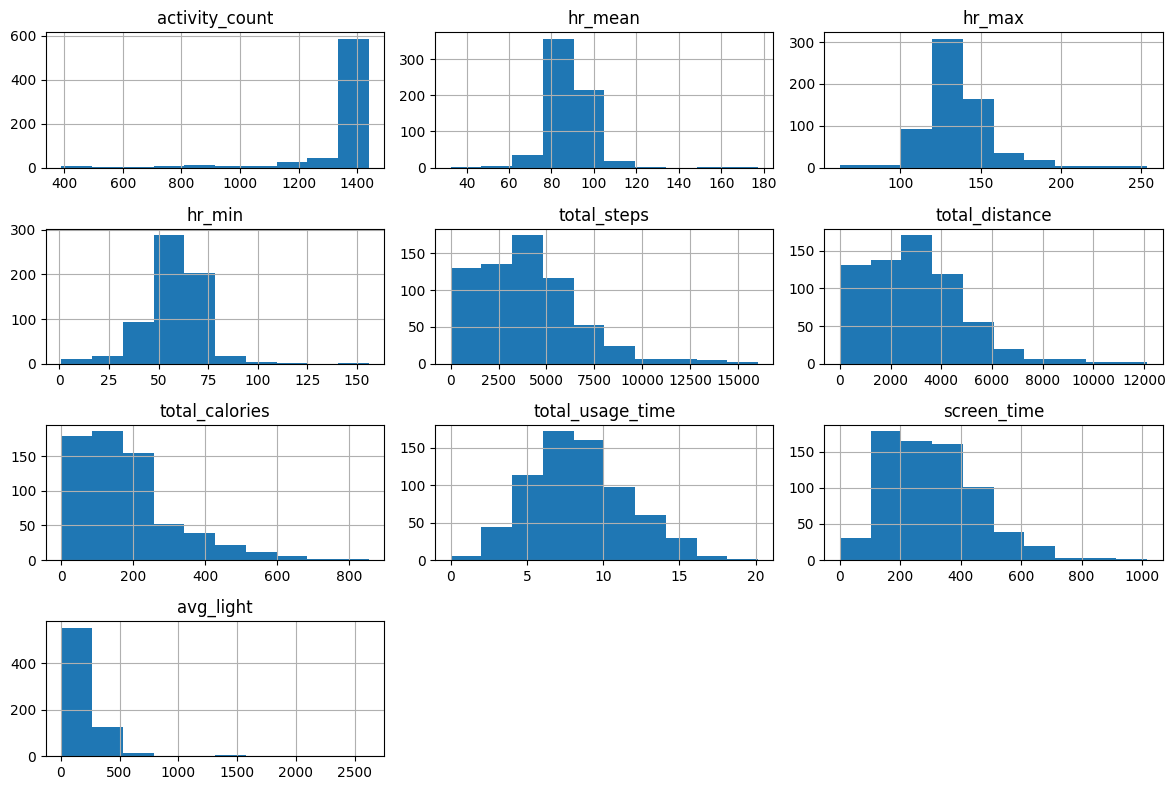

In [130]:
import matplotlib.pyplot as plt

final_data.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

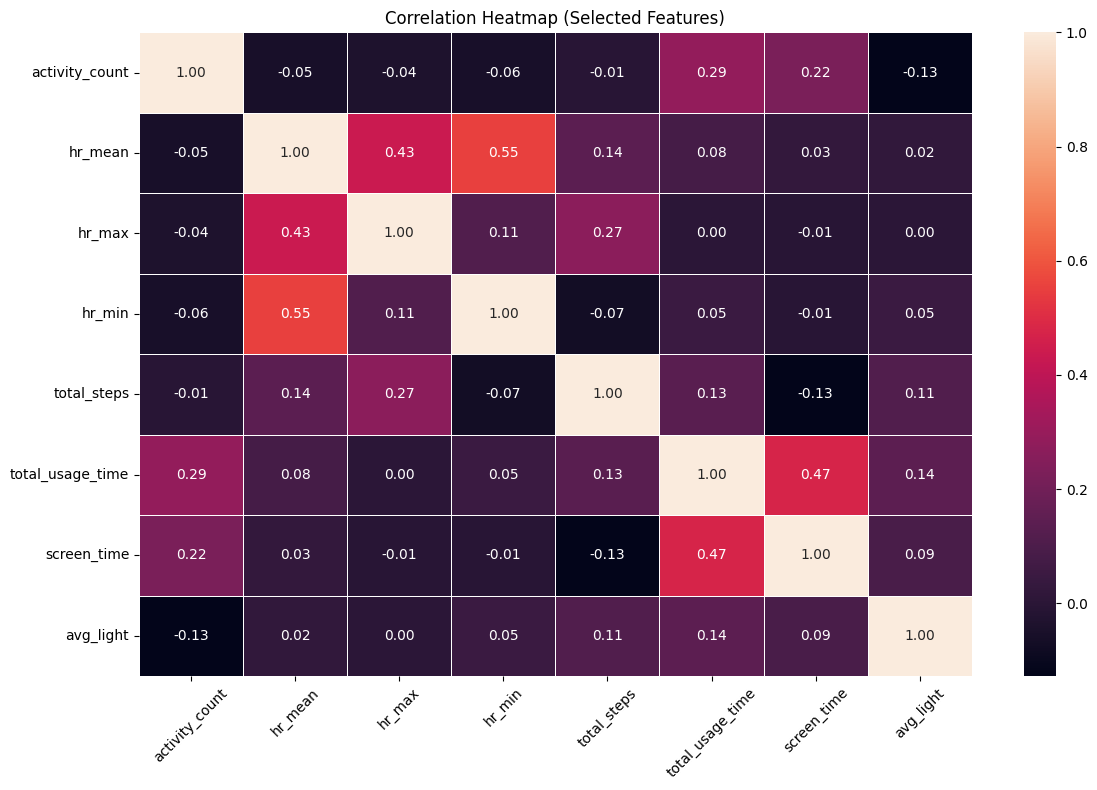

In [131]:
import seaborn as sns

selected_features = final_data[[
    "activity_count",
    "hr_mean",
    "hr_max",
    "hr_min",
    "total_steps",
    "total_usage_time",
    "screen_time",
    "avg_light"
]]

corr_matrix = selected_features.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Selected Features)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#### <font color='#1F4E79' size='14' face='Calibri'><b>7. Clustering Approach</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

After cleaning the data, the next step is to prepare it for analysis.

Since the data is recorded at a very detailed time level, it needs to be converted into a daily format. This helps in analysing overall behaviour patterns for each user.

In this section, the timestamp is used to create a date column, and the data is grouped on a daily basis.



In [132]:
selected_features = selected_features.fillna(selected_features.mean())

In [133]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(selected_features)

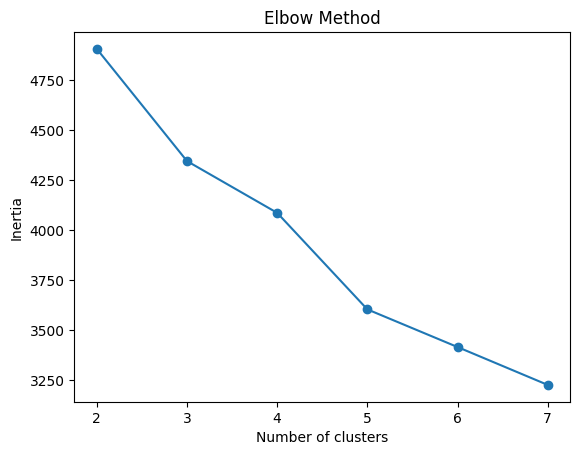

In [134]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.plot(range(2,8), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The elbow point was observed around **k = 3**, show that three clusters are suitable for this dataset.

In [135]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)

final_data["cluster"] = kmeans.fit_predict(scaled_data)

In [136]:
from sklearn.metrics import silhouette_score
for k in [3,4,5]:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(scaled_data)
    
    score = silhouette_score(scaled_data, labels)
    print(k, round(score, 3))

3 0.161
4 0.164
5 0.17


In [137]:
numeric_cols = final_data.select_dtypes(include=["number"]).columns

cluster_summary = final_data.groupby("cluster").mean(numeric_only=True)
cluster_summary = cluster_summary.drop(columns=["cluster"], errors="ignore")
cluster_summary

,activity_count,hr_mean,hr_max,hr_min,total_steps,total_distance,total_calories,total_usage_time,screen_time,avg_light
cluster,,,,,,,,,,
0,1417.964602,92.679102,141.721678,63.042873,4412.363914,3291.996951,199.227354,10.331519,388.294985,237.379898
1,1407.060897,83.101791,127.628612,51.434982,3350.469751,2513.427559,141.972359,6.762067,234.118590,116.212161
2,844.265306,90.965434,138.170280,61.672053,4395.466667,3256.865953,199.036381,5.487693,202.632653,320.330093


In [138]:
final_data["cluster"].value_counts()

cluster
0    339
1    312
2     49
Name: count, dtype: int64

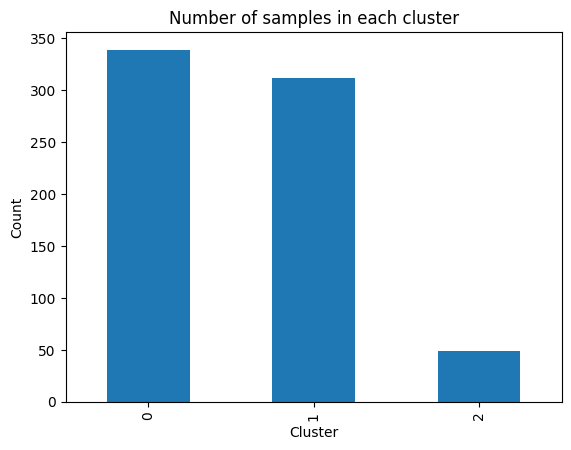

In [139]:
final_data["cluster"].value_counts().plot(kind="bar")

plt.title("Number of samples in each cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## <font color='#1F4E79' face='Calibri'><b>5.3 Cluster Interpretation</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

Cluster 0: High activity and usage  
Cluster 1: Moderate behaviour  
Cluster 2: Lower activity  

</div>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

<b>Observation:</b> Clusters represent behaviour patterns, not strict lifestyle categories.

</div>

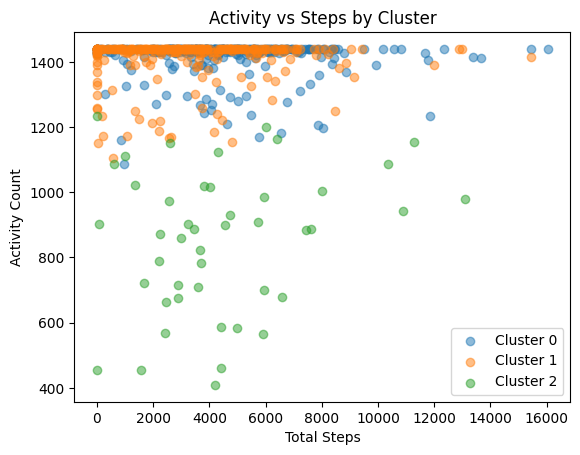

In [140]:
for c in sorted(final_data["cluster"].unique()):
    subset = final_data[final_data["cluster"] == c]
    plt.scatter(subset["total_steps"], subset["activity_count"], label=f"Cluster {c}", alpha=0.5)

plt.xlabel("Total Steps")
plt.ylabel("Activity Count")
plt.title("Activity vs Steps by Cluster")
plt.legend()
plt.show()

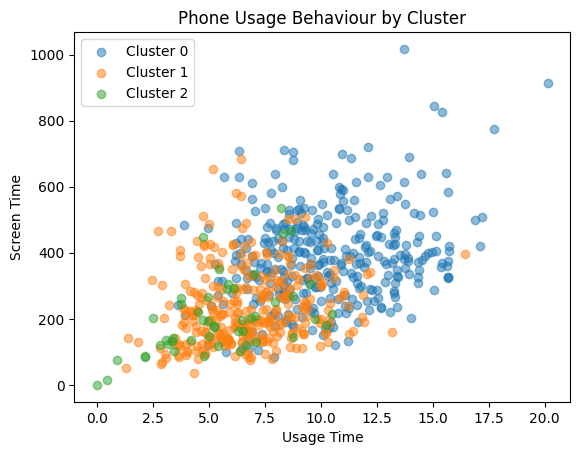

In [141]:
for c in sorted(final_data["cluster"].unique()):
    subset = final_data[final_data["cluster"] == c]
    plt.scatter(subset["total_usage_time"], subset["screen_time"], label=f"Cluster {c}", alpha=0.5)

plt.xlabel("Usage Time")
plt.ylabel("Screen Time")
plt.title("Phone Usage Behaviour by Cluster")
plt.legend()
plt.show()

<Figure size 600x400 with 0 Axes>

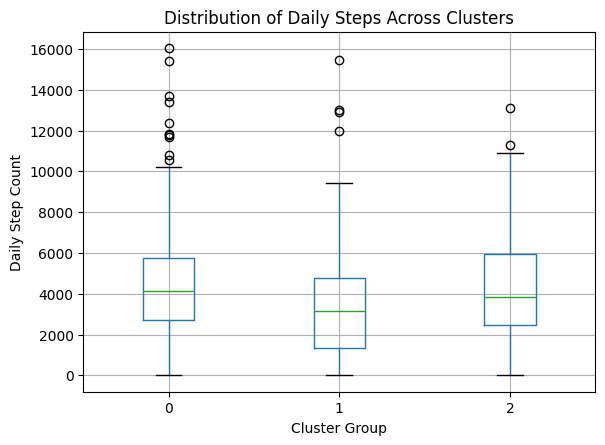

In [142]:
plt.figure(figsize=(6,4))

final_data.boxplot(column="total_steps", by="cluster")

plt.title("Distribution of Daily Steps Across Clusters")
plt.suptitle("")
plt.xlabel("Cluster Group")
plt.ylabel("Daily Step Count")
plt.show()

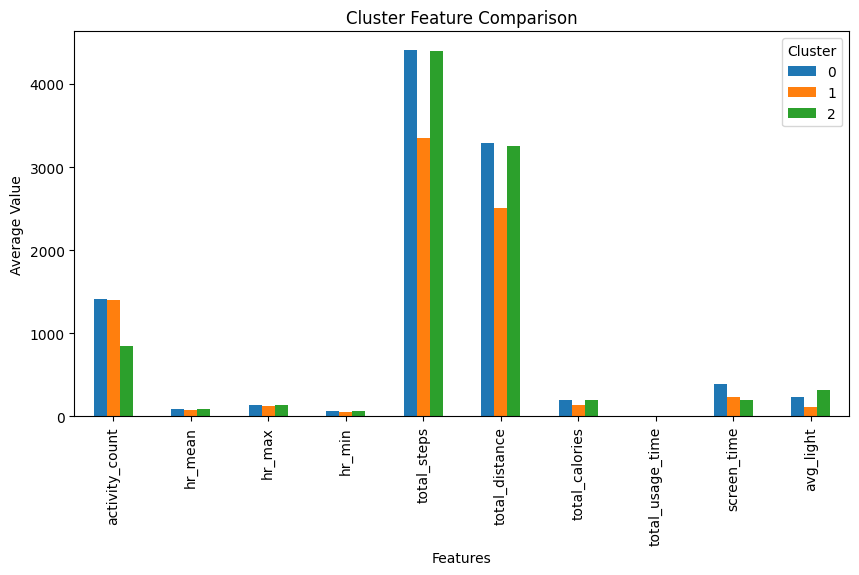

In [143]:
cluster_summary.T.plot(kind="bar", figsize=(10,5))

plt.title("Cluster Feature Comparison")
plt.xlabel("Features")
plt.ylabel("Average Value")
plt.legend(title="Cluster")
plt.show()

In [144]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, final_data["cluster"])
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.161


##### <font color='#1F4E79' font-size='17px'  face='Calibri'><b>5.2 Cluster Quality</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

Silhouette score ≈ 0.16.

</div>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

<b>Observation:</b> Clusters have weak separation due to overlapping human behaviour patterns.

</div>

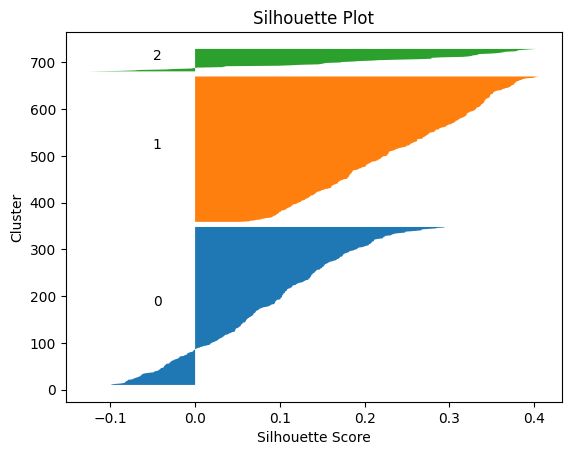

In [145]:
from sklearn.metrics import silhouette_samples
import numpy as np

sample_values = silhouette_samples(scaled_data, final_data["cluster"])

y_lower = 10

for i in sorted(final_data["cluster"].unique()):
    cluster_values = sample_values[final_data["cluster"] == i]
    cluster_values.sort()
    
    size = len(cluster_values)
    y_upper = y_lower + size
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values
    )
    
    plt.text(-0.05, y_lower + size / 2, str(i))
    y_lower = y_upper + 10

plt.title("Silhouette Plot")
plt.xlabel("Silhouette Score")
plt.ylabel("Cluster")
plt.show()

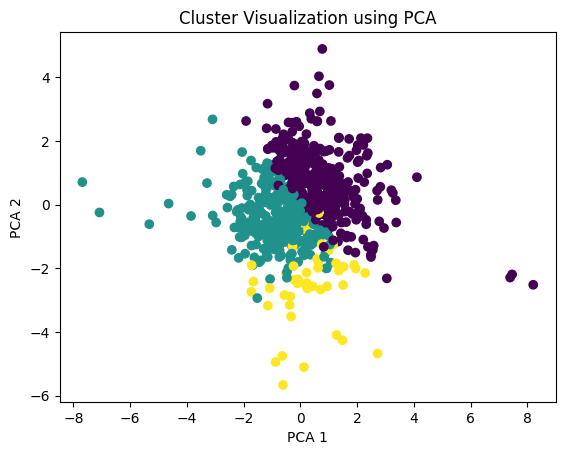

In [146]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(scaled_data)

plt.scatter(reduced[:, 0], reduced[:, 1], c=final_data["cluster"])

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cluster Visualization using PCA")
plt.show()

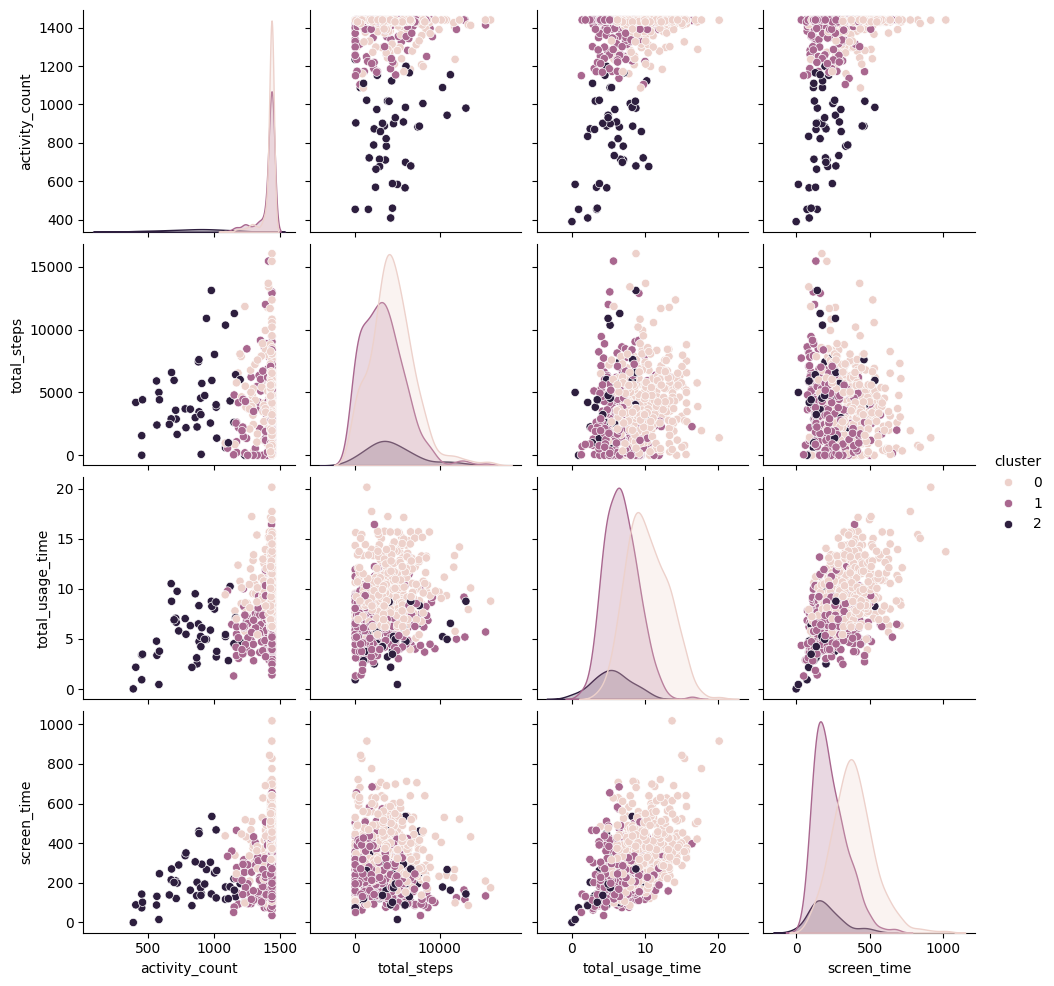

In [147]:
import seaborn as sns

sns.pairplot(final_data, hue="cluster", vars=[
    "activity_count",
    "total_steps",
    "total_usage_time",
    "screen_time"
])

In [148]:
cluster_summary = final_data.groupby("cluster").mean(numeric_only=True)
cluster_summary

,activity_count,hr_mean,hr_max,hr_min,total_steps,total_distance,total_calories,total_usage_time,screen_time,avg_light
cluster,,,,,,,,,,
0,1417.964602,92.679102,141.721678,63.042873,4412.363914,3291.996951,199.227354,10.331519,388.294985,237.379898
1,1407.060897,83.101791,127.628612,51.434982,3350.469751,2513.427559,141.972359,6.762067,234.118590,116.212161
2,844.265306,90.965434,138.170280,61.672053,4395.466667,3256.865953,199.036381,5.487693,202.632653,320.330093


In [149]:
final_data.columns

Index(['subject_id', 'date', 'activity_count', 'hr_mean', 'hr_max', 'hr_min',
       'total_steps', 'total_distance', 'total_calories', 'total_usage_time',
       'screen_time', 'avg_light', 'cluster'],
      dtype='object')

In [150]:
metrics_file = [f for f in data_files if "metrics" in f.name][0]

metrics = pd.read_csv(metrics_file)

metrics.head()

,subject_id,sleep_date,lifelog_date,Q1,Q2,Q3,S1,S2,S3
0,id01,2024-06-27,2024-06-26,0,0,0,0,0,1
1,id01,2024-06-28,2024-06-27,0,0,0,0,1,1
2,id01,2024-06-29,2024-06-28,1,0,0,1,1,1
3,id01,2024-06-30,2024-06-29,1,0,1,2,0,0
4,id01,2024-07-01,2024-06-30,0,1,1,1,1,1


In [151]:
metrics.columns

Index(['subject_id', 'sleep_date', 'lifelog_date', 'Q1', 'Q2', 'Q3', 'S1',
       'S2', 'S3'],
      dtype='object')

In [152]:
metrics["date"] = pd.to_datetime(metrics["lifelog_date"]).dt.date

In [153]:
final_data = final_data.merge(
    metrics[["subject_id", "date", "Q1", "Q2", "Q3"]],
    on=["subject_id", "date"],
    how="left"
)

In [154]:
final_data[["Q1","Q2","Q3"]].head()

,Q1,Q2,Q3
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,1.0
4,0.0,1.0,1.0


In [155]:
final_data = final_data.dropna(subset=["Q1"])

In [156]:
target = "Q1"

In [157]:
final_data["Q1"].value_counts()

Q1
0.0    227
1.0    223
Name: count, dtype: int64

In [158]:
cluster_sleep = final_data.groupby("cluster")["Q1"].mean().reset_index()
cluster_sleep

,cluster,Q1
0,0,0.509259
1,1,0.512438
2,2,0.303030


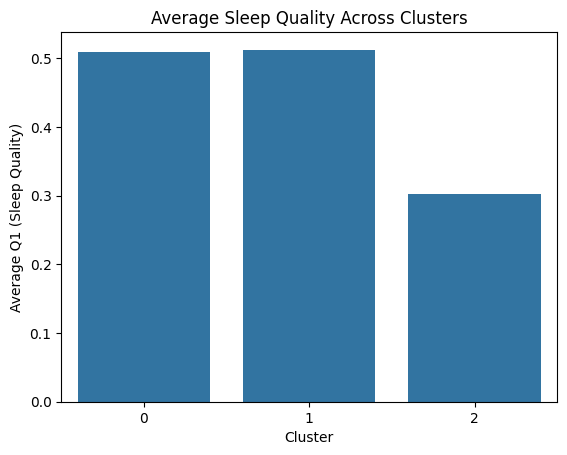

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="cluster", y="Q1", data=cluster_sleep)

plt.title("Average Sleep Quality Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Average Q1 (Sleep Quality)")
plt.show()

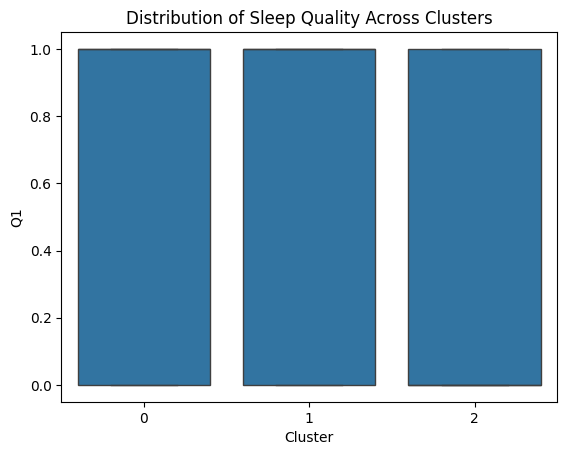

In [160]:
sns.boxplot(x="cluster", y="Q1", data=final_data)

plt.title("Distribution of Sleep Quality Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Q1")
plt.show()

In [161]:
from scipy.stats import f_oneway

groups = [
    final_data[final_data["cluster"] == c]["Q1"]
    for c in final_data["cluster"].unique()
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 2.6558365878625714
p-value: 0.0713483601180727


In [162]:
# stress
final_data.groupby("cluster")["Q3"].mean()

cluster
0    0.615741
1    0.601990
2    0.484848
Name: Q3, dtype: float64

In [163]:
# fatigue
final_data.groupby("cluster")["Q2"].mean()

cluster
0    0.560185
1    0.557214
2    0.606061
Name: Q2, dtype: float64

##### <font color='#1F4E79' size='8' face='Calibri'><b> 8 Model Performance</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

**8.1 Objective**

The objective of this section is to evaluate whether behavioural features can predict overall lifestyle patterns using machine learning models.

**8.2 Lifestyle Target Construction**

A combined lifestyle score was created using sleep quality (Q1), fatigue (Q2), and stress (Q3). This provides a more holistic representation of an individual’s wellbeing.
</div>



In [164]:
final_data["lifestyle_score"] = final_data[["Q1", "Q2", "Q3"]].mean(axis=1)

final_data["lifestyle_label"] = (final_data["lifestyle_score"] >= 0.5).astype(int)

# **Machine Learning Model**

In [165]:
# Target
y = final_data["lifestyle_label"]

# Features
X = final_data.drop(columns=[
    "subject_id",
    "date",
    "Q1",
    "Q2",
    "Q3",
    "lifestyle_score",
    "lifestyle_label"
])

# Fill missing values
X = X.fillna(X.median())

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODELS
## **1. Linear Regression**

In [168]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

## **2. Rabndom Forest Classifier** 

In [169]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## **3. SVM Classifier** 

In [170]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [171]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_scaled, y_train)

gb_pred = gb.predict(X_test_scaled)

In [172]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate(y_true, y_pred, name):
    print(name)
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))
    print("-"*30)

evaluate(y_test, lr_pred, "Logistic")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, svm_pred, "SVM")
evaluate(y_test, gb_pred, "Gradient Boosting")

Logistic
Accuracy: 0.5444444444444444
Precision: 0.6111111111111112
Recall: 0.7719298245614035
F1: 0.6821705426356589
------------------------------
Random Forest
Accuracy: 0.5444444444444444
Precision: 0.625
Recall: 0.7017543859649122
F1: 0.6611570247933884
------------------------------
SVM
Accuracy: 0.5
Precision: 0.581081081081081
Recall: 0.7543859649122807
F1: 0.6564885496183206
------------------------------
Gradient Boosting
Accuracy: 0.5666666666666667
Precision: 0.6363636363636364
Recall: 0.7368421052631579
F1: 0.6829268292682927
------------------------------


In [177]:
 from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:  ", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores:   [0.48888889 0.54444444 0.42222222 0.45555556 0.35555556]
Mean accuracy: 0.4533333333333333


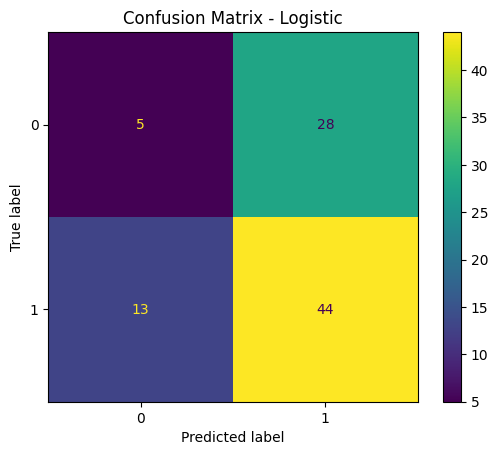

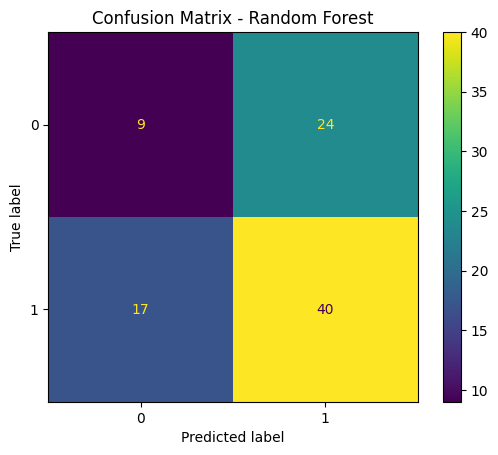

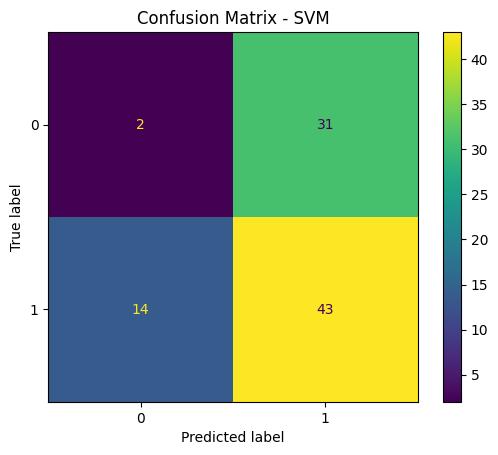

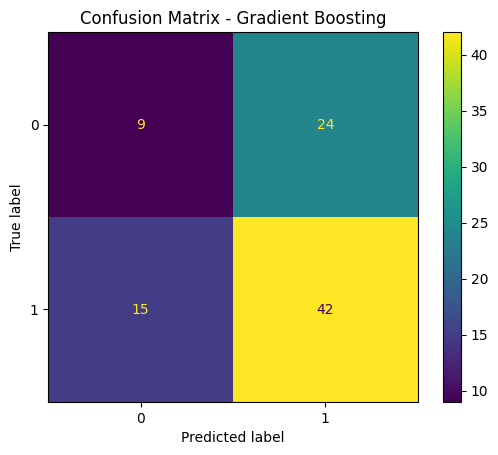

In [173]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    "Logistic": lr_pred,
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "Gradient Boosting": gb_pred
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

avg_light           0.141744
total_usage_time    0.134529
screen_time         0.114083
hr_min              0.104582
hr_mean             0.104009
hr_max              0.090706
total_calories      0.083806
total_distance      0.079023
total_steps         0.077221
activity_count      0.058016
cluster             0.012281
dtype: float64


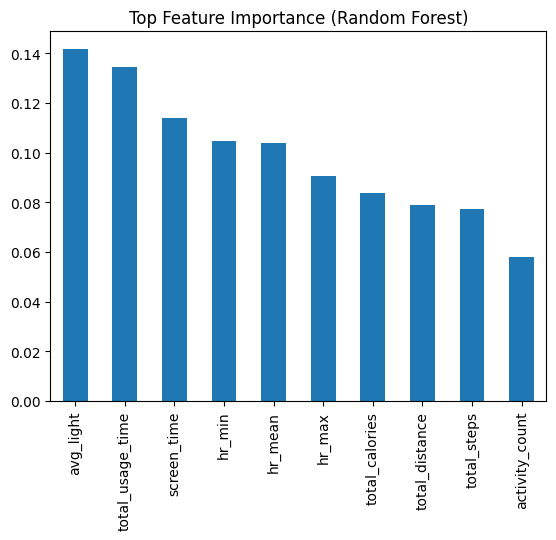

In [174]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

feature_importance.head(10).plot(kind="bar")
plt.title("Top Feature Importance (Random Forest)")
plt.show()

##### <font color='#1F4E79' size='4' face='Calibri'><b>7.2 Feature Importance Interpretation</b></font>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

Feature importance results show that:

- Light exposure (avg_light) has the highest contribution  
- Phone usage (total_usage_time, screen_time) also plays a major role  
- Heart rate features have moderate importance  
- Physical activity features (steps, activity_count) have relatively lower importance  
- Cluster label has very low importance  

</div>

<div style="font-family:'Calibri'; font-size:17px; color:black;">

<b>Observation:</b> Lifestyle patterns are influenced more by environmental and phone usage behaviour than physical activity alone.

</div>